# Import des bibliothèques nécessaires

In [1]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Présentation de la problématique et importation des données

## Présentation de la problématique


Le jeu de données "California Housing" contient des informations sur les logements en Californie, aux États-Unis, ainsi que leur valeur. 
L'objectif de ce jeu de projet **prédire la valeur des logements en fonction de leurs caractéristiques**.



Le fichier de données peut être téléchargé à partir de la page Kaggle suivante : [California Housing](https://www.kaggle.com/harrywang/housing)



Les variables présentes dans le jeu de données sont les suivantes :

- `longitude` : Longitude de la localisation du logement
- `latitude` : Latitude de la localisation du logement
- `housing_median_age` : Âge médian des logements dans la région
- `total_rooms` : Nombre total de chambres dans la région
- `total_bedrooms` : Nombre total de chambres à coucher dans la région
- `population` : Population totale dans la région
- `households` : Nombre total de ménages dans la région
- `median_income` : Revenu médian des ménages dans la région
- `median_house_value` : Valeur médiane des maisons dans la région
- `ocean_proximity` : Proximité de la maison par rapport à l'océan (côte, île, etc.)









## Importation et nettoyage des données

In [2]:
import pandas as pd
data = pd.read_csv('housing.csv',decimal=".")

In [3]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
#Information sur la base de données
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
#Analyse des données manquantes
data.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [6]:
# Description des tables
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [7]:
# Hypothèse : les régions où 'total_bedrooms' est manquant n'ont pas de chambres
# Remplacement des valeurs manquantes par 0
data['total_bedrooms'] = data['total_bedrooms'].fillna(0)

# Vérification des valeurs manquantes restantes
data.isnull().sum()


longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

# Description des biens de la base de données

## Description des variables numériques

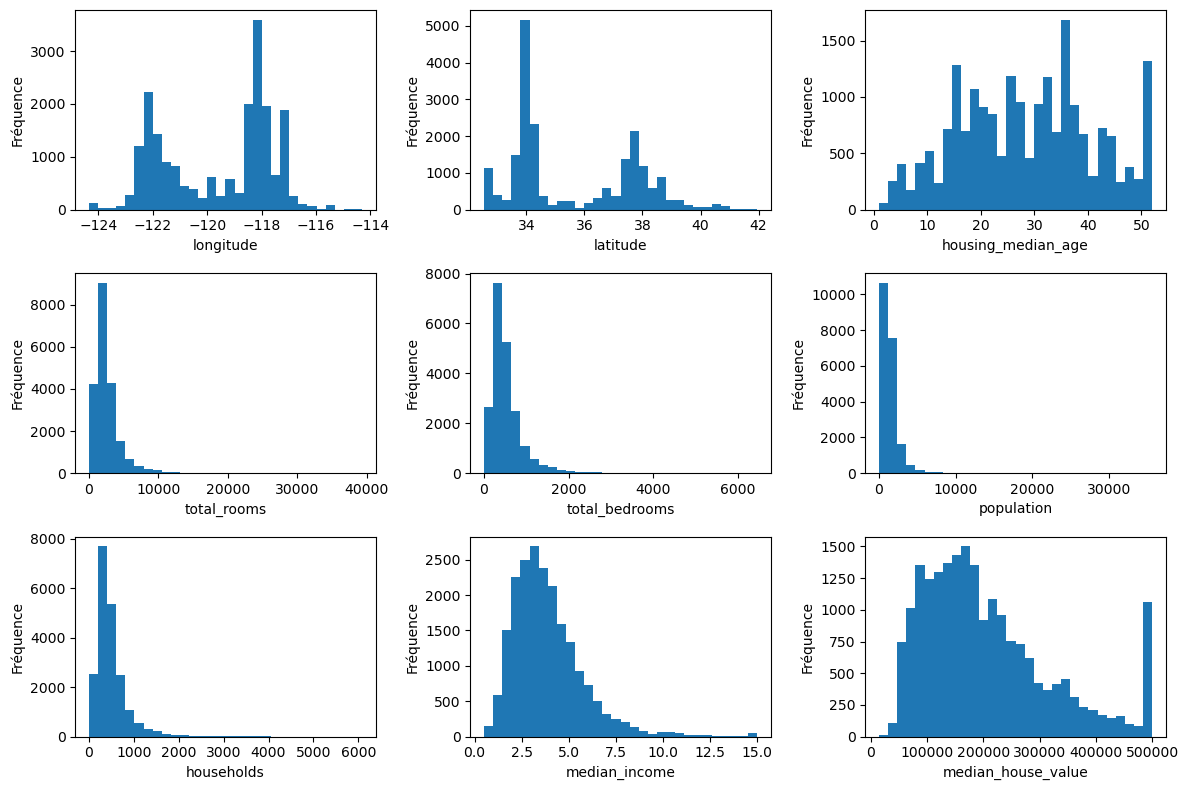

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as  np
# Description univariée des variables numériques

# Sélection des variables quantitatives
quant_vars = data.select_dtypes(include=np.number).columns

# Création des subplots pour chaque variable quantitative sur une même figure
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(12, 8))
axs = axs.flatten()
for i, var in enumerate(quant_vars):
    axs[i].hist(data[var], bins=30)
    axs[i].set_xlabel(var)
    axs[i].set_ylabel('Fréquence')
plt.tight_layout()
plt.show()


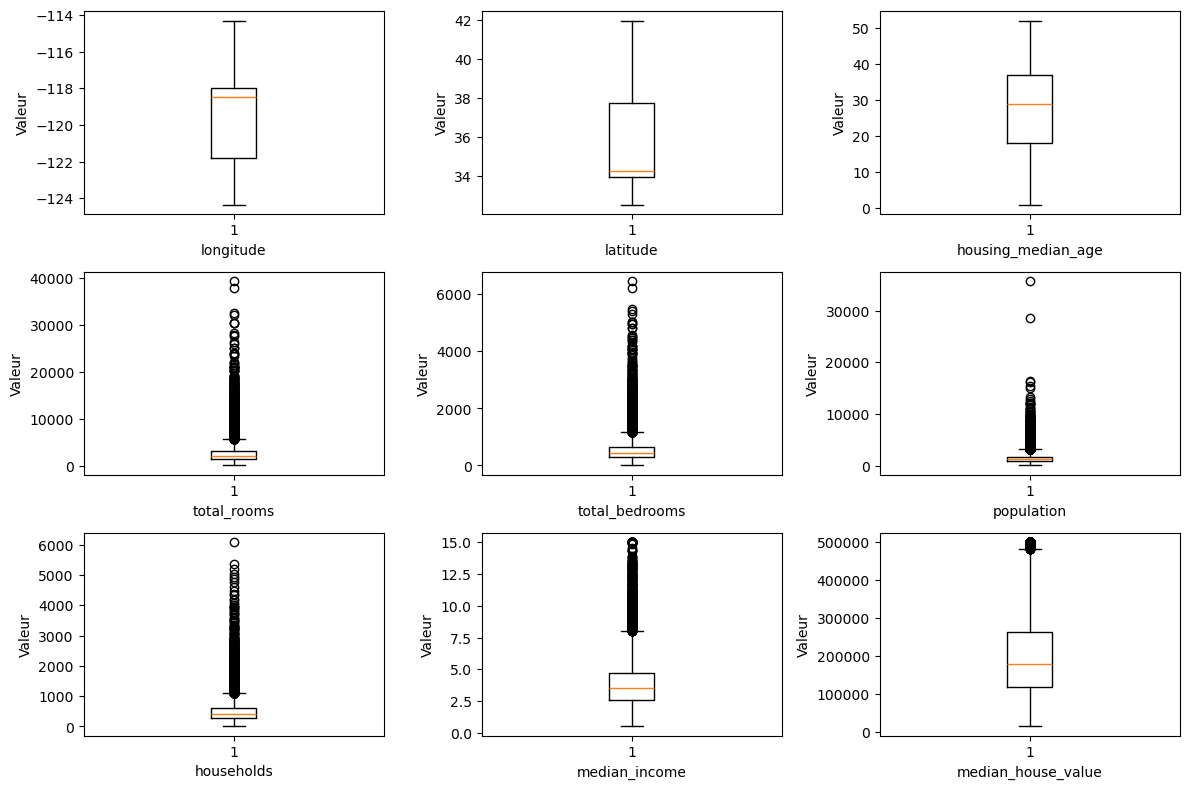

In [9]:
quant_vars = data.select_dtypes(include=np.number).columns
# Création des subplots pour chaque variable quantitative sur une même figure
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(12, 8))
axs = axs.flatten()
for i, var in enumerate(quant_vars):
    axs[i].boxplot(data[var])
    axs[i].set_xlabel(var)
    axs[i].set_ylabel('Valeur')
plt.tight_layout()
plt.show()

## Description de la variable catégorielle 'ocean_proximity'

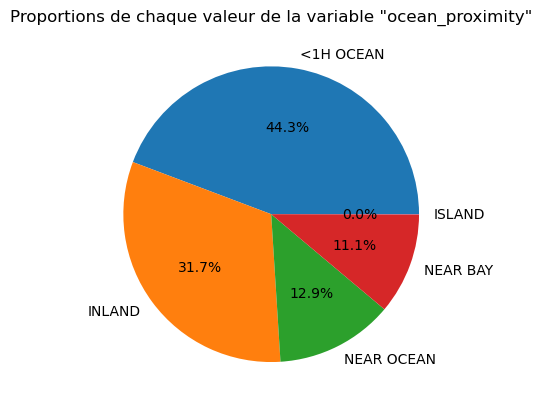

In [10]:


# Calcul des proportions pour chaque valeur de la variable catégorielle
prop_counts = data['ocean_proximity'].value_counts(normalize=True)

# Création du pie chart
plt.pie(prop_counts, labels=prop_counts.index, autopct='%1.1f%%')
plt.title('Proportions de chaque valeur de la variable "ocean_proximity"')
plt.show()

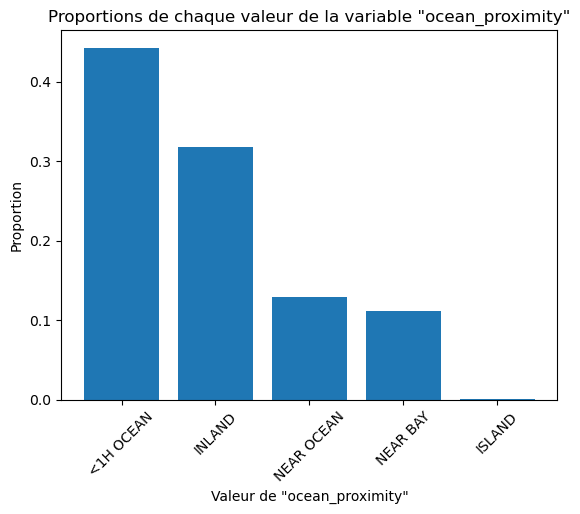

In [11]:

# Calcul des proportions pour chaque valeur de la variable catégorielle
prop_counts = data['ocean_proximity'].value_counts(normalize=True)

# Création du barplot
plt.bar(x=prop_counts.index, height=prop_counts)
plt.xticks(rotation=45)
plt.xlabel('Valeur de "ocean_proximity"')
plt.ylabel('Proportion')
plt.title('Proportions de chaque valeur de la variable "ocean_proximity"')
plt.show()

# Analyses bivariées et sélection des variables pertinentes

## Corrélation entre les variables numériques

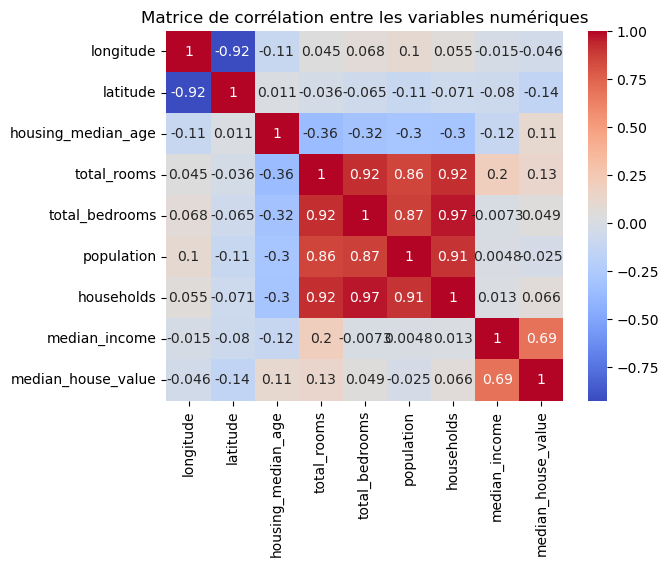

In [12]:
import seaborn as sns
# Corrélation entre les variables numériques
corr_matrix = data.select_dtypes(include=np.number).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matrice de corrélation entre les variables numériques')
plt.show()


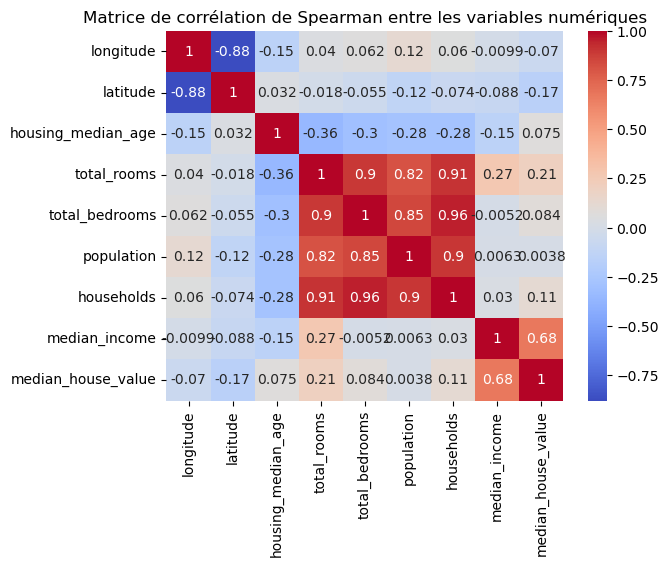

In [13]:
# Sélection des variables numériques
num_vars = data.select_dtypes(include=np.number).columns
# Calcul de la matrice de corrélation de Spearman
corr_matrix = data[num_vars].corr(method='spearman')

# Affichage de la matrice de corrélation de Spearman
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matrice de corrélation de Spearman entre les variables numériques')
plt.show()

## Relation entre la variable cible 'median_house_value' et les variables numériques

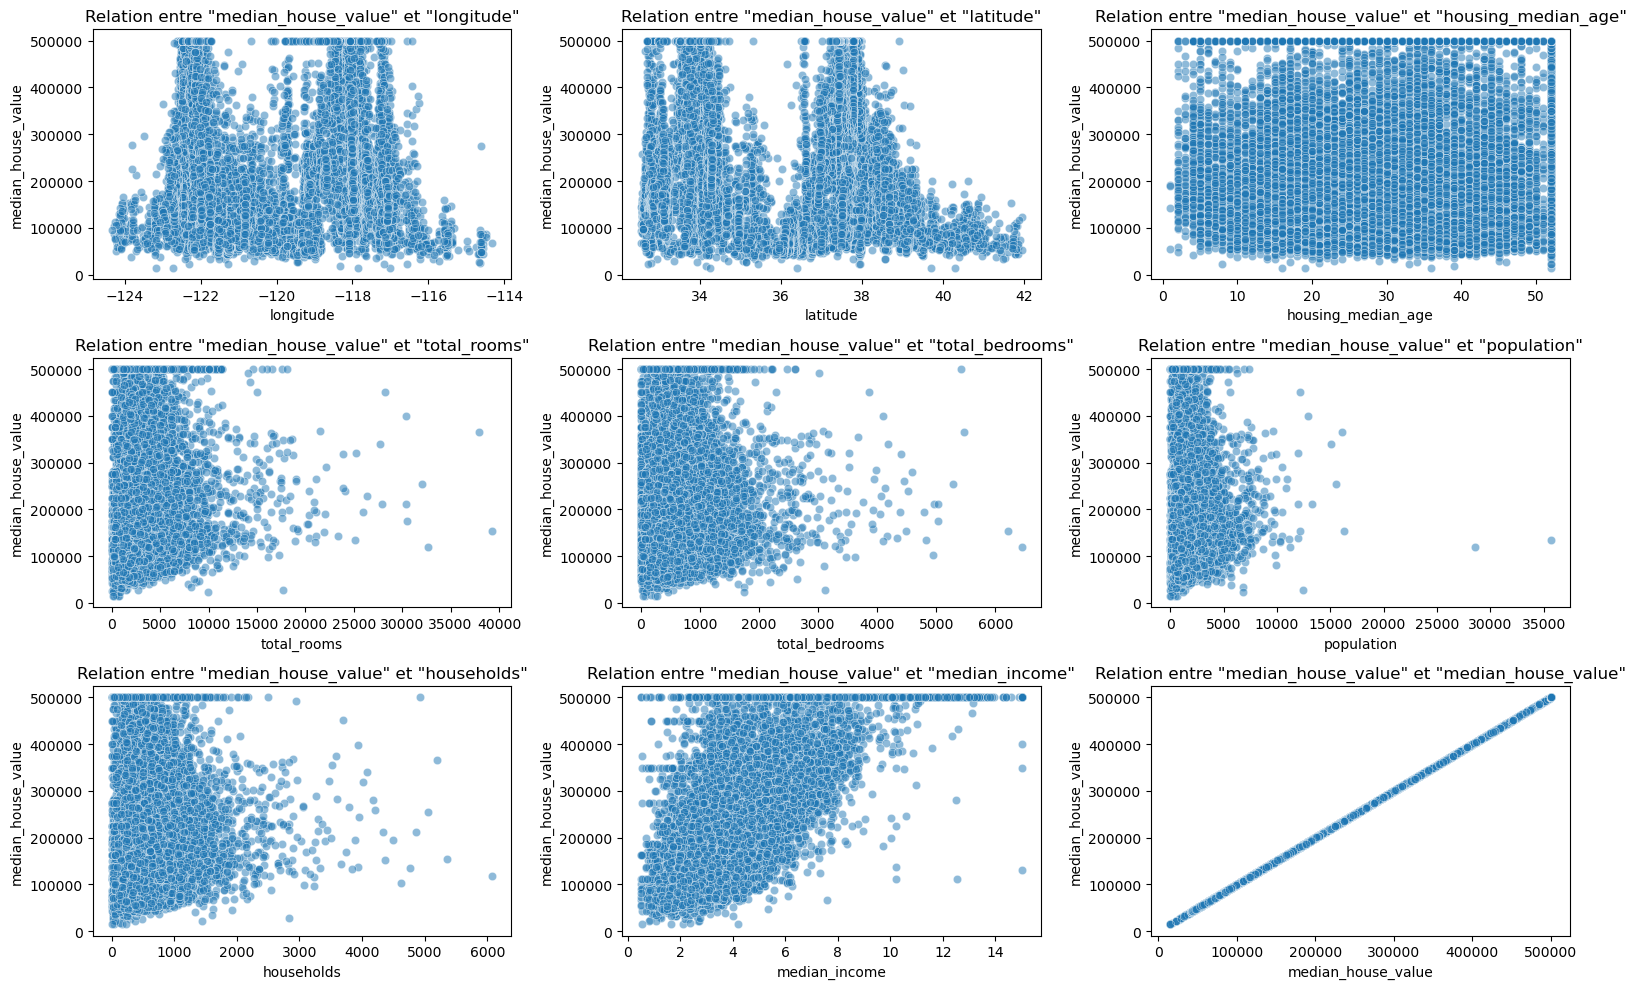

In [14]:
# Sélection des variables numériques
num_vars = data.select_dtypes(include=np.number).columns

# Calcul de la taille de la matrice des subplots en fonction du nombre de variables numériques
n_cols = 3
n_rows = int(np.ceil(len(num_vars) / n_cols))

# Affichage des scatterplots pour chaque variable numérique sur une même figure avec des subplots
fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(16, 10))
axs = axs.flatten()

for i, var in enumerate(num_vars):
    sns.scatterplot(x=var, y='median_house_value', data=data, alpha=0.5, ax=axs[i])
    axs[i].set_title('Relation entre "median_house_value" et "{}"'.format(var))

# Ajout des titres et des étiquettes des axes
plt.tight_layout()
plt.show()


## Relation entre la variable cible 'median_house_value' et la variable catégorielle 'ocean_proximity'


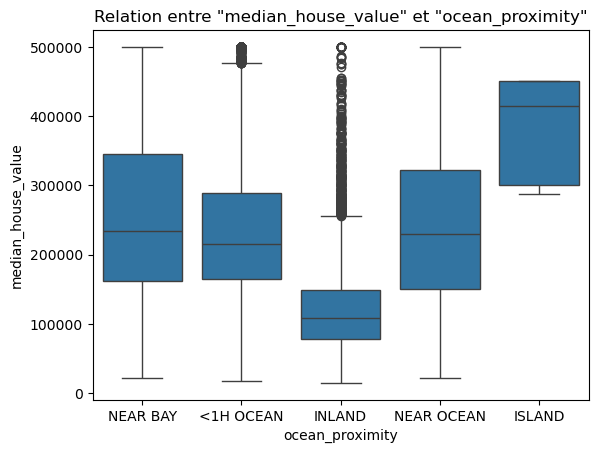

In [15]:
sns.boxplot(x='ocean_proximity', y='median_house_value', data=data)
plt.title('Relation entre "median_house_value" et "ocean_proximity"')
plt.show()


## Relation entre les variables numériques

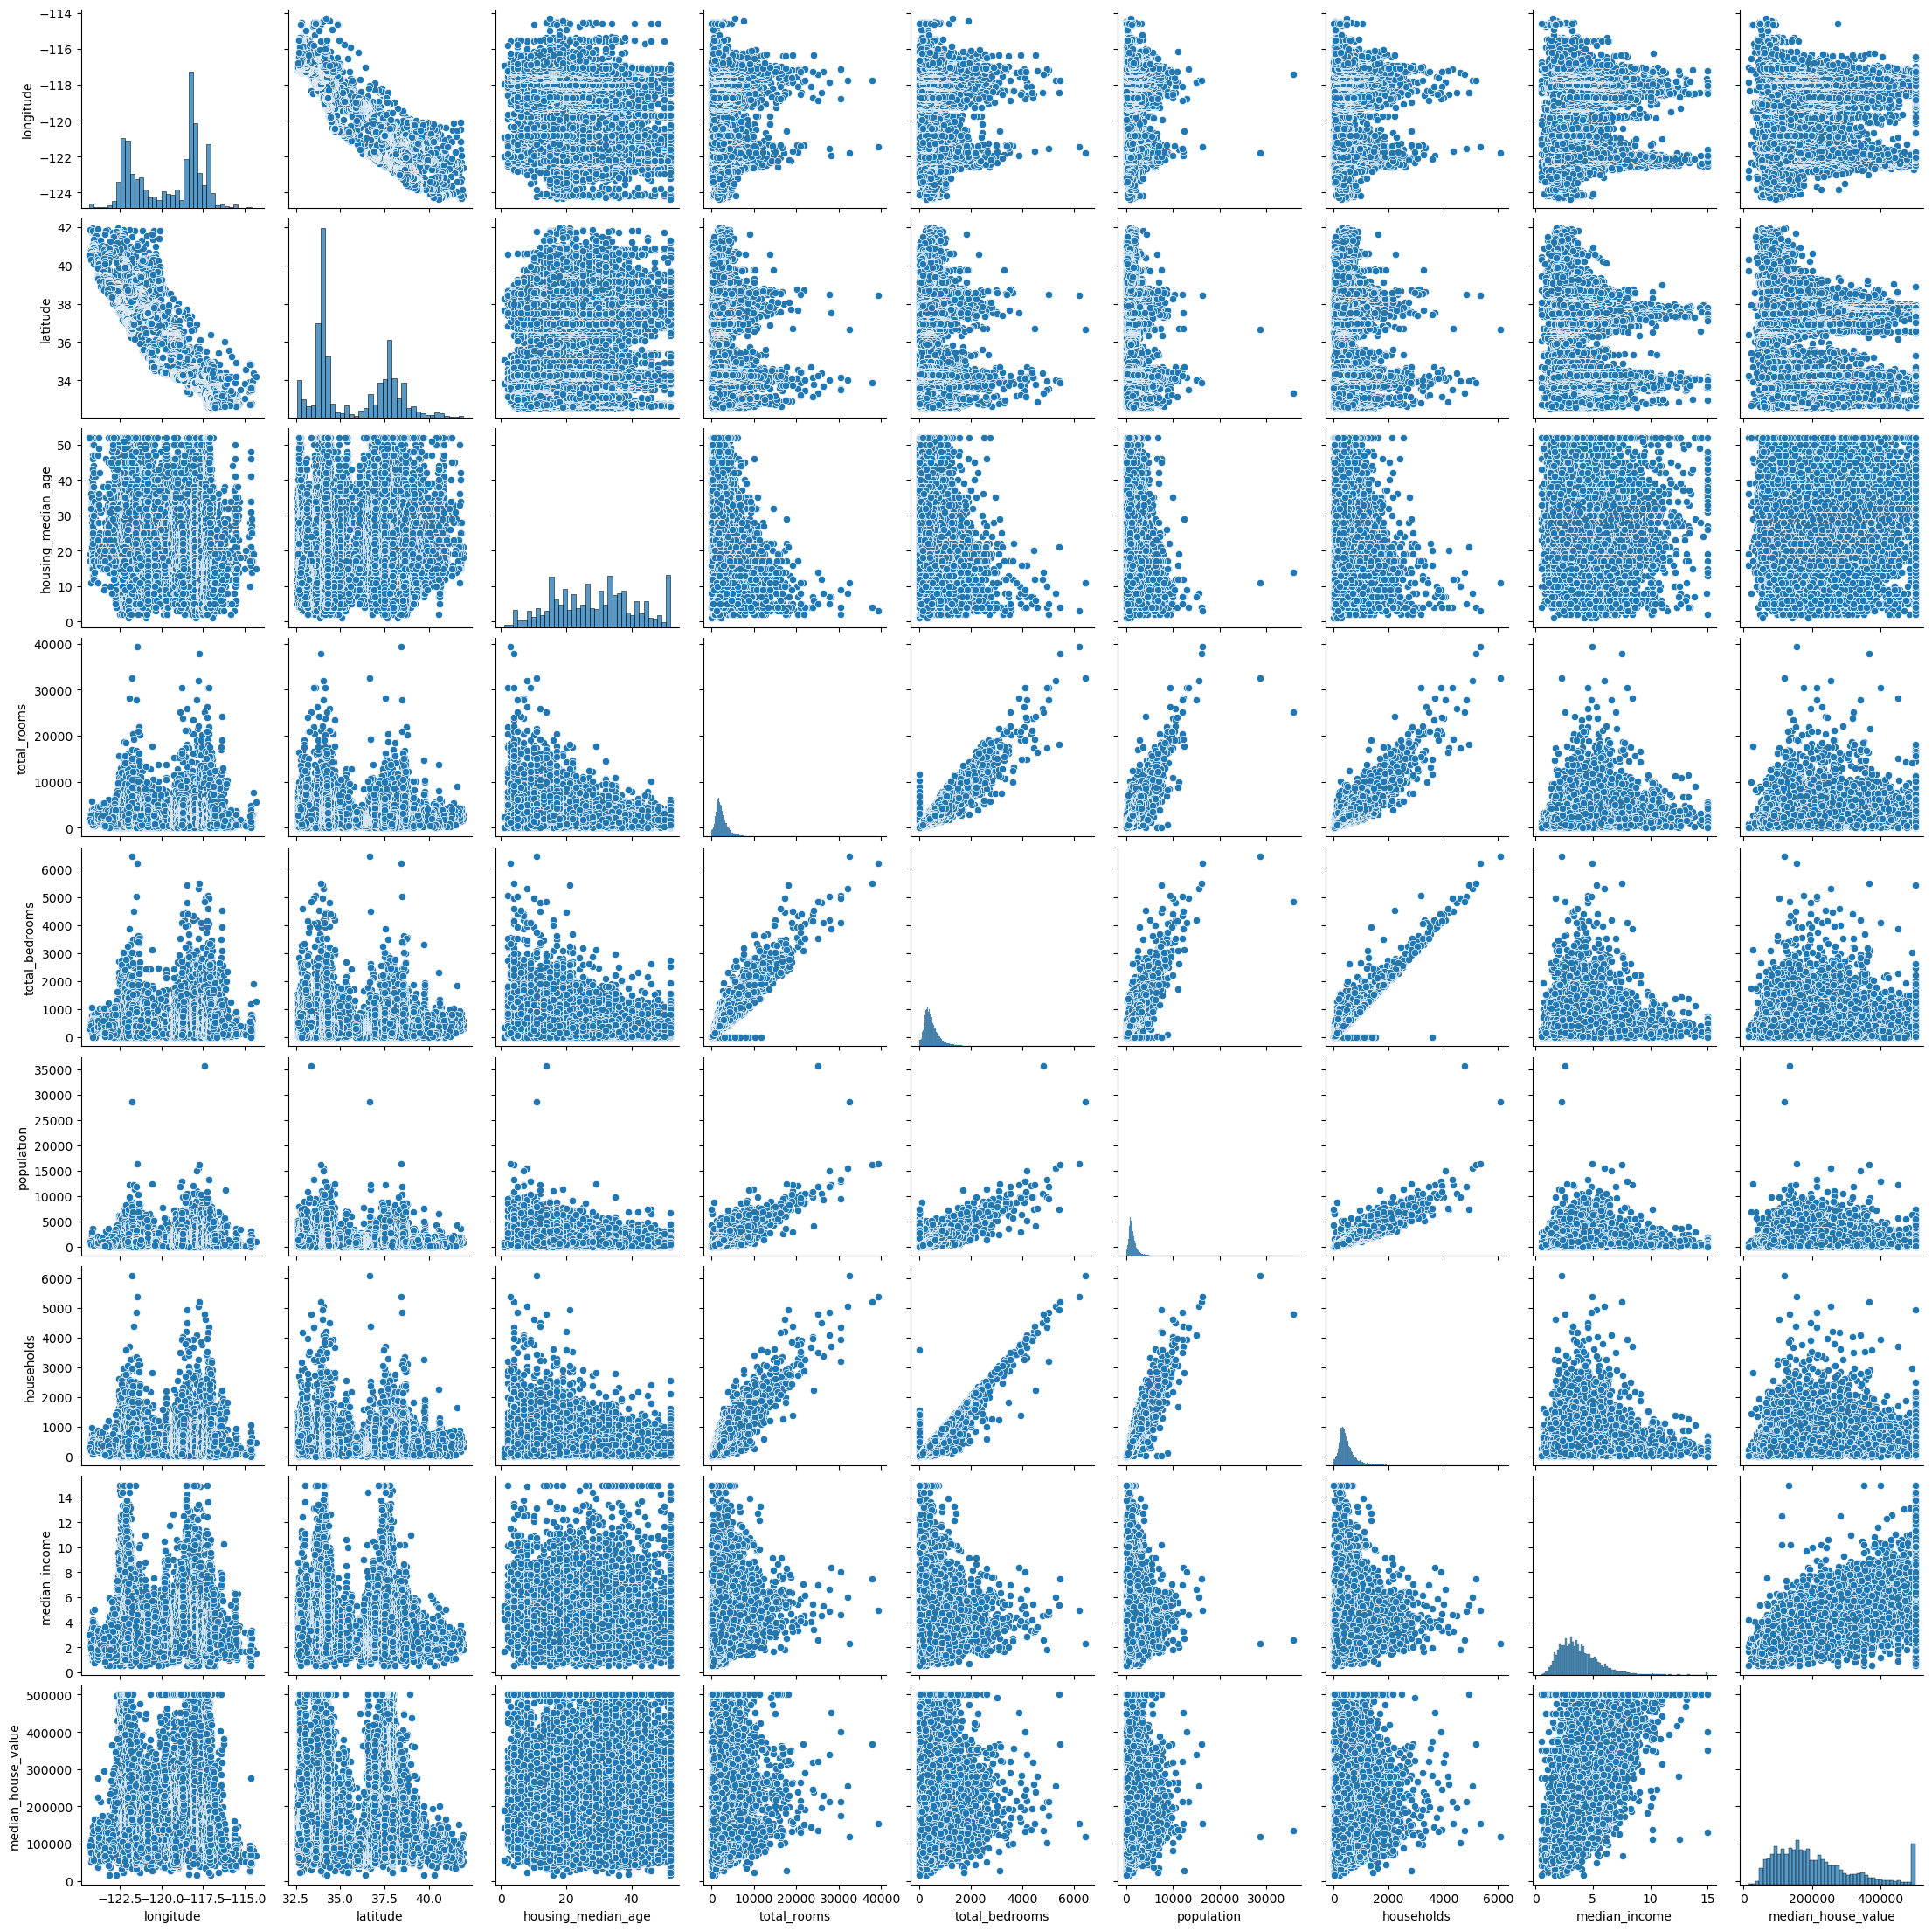

In [16]:
sns.pairplot(data[num_vars])
plt.show()

# Modélisation du prix du bien immobilier

## Variables

In [17]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Sélection des variables catégorielles
cat_vars = ['ocean_proximity']

# Encodage One-Hot
encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)

# Transformation
cat_encoded = encoder.fit_transform(data[cat_vars])

# Création du DataFrame encodé avec le bon index
cat_data = pd.DataFrame(
    cat_encoded,
    columns=encoder.get_feature_names_out(cat_vars),
    index=data.index
)

# Remplacement des variables catégorielles par les variables encodées
data = pd.concat(
    [data.drop(columns=cat_vars), cat_data],
    axis=1
)

data


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,0.0,1.0,0.0,0.0,0.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,0.0,1.0,0.0,0.0,0.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,0.0,1.0,0.0,0.0,0.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,0.0,1.0,0.0,0.0,0.0


In [18]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,0.0,1.0,0.0,0.0,0.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,0.0,1.0,0.0,0.0,0.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,0.0,1.0,0.0,0.0,0.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,0.0,1.0,0.0,0.0,0.0


In [19]:
# Séparation des données en variables explicatives et variable cible
X = data.drop('median_house_value', axis=1)
y = data['median_house_value']

In [20]:
y

0        452600.0
1        358500.0
2        352100.0
3        341300.0
4        342200.0
           ...   
20635     78100.0
20636     77100.0
20637     92300.0
20638     84700.0
20639     89400.0
Name: median_house_value, Length: 20640, dtype: float64

## Diviser la base en train en test

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Arbre de régression non optimisé

In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)


In [ ]:
# Affichage de l'arbre
plt.figure(figsize=(15,10))
plot_tree(tree, feature_names=X_train.columns, filled=True)
plt.show()

In [ ]:
# Affichage de l'importance des variables
importances = pd.Series(tree.feature_importances_, index=X_train.columns)
importances_sorted = importances.sort_values()
plt.barh(importances_sorted.index, importances_sorted)
plt.title('Importance des variables dans la prédiction du prix des maisons')
plt.xlabel('Importance')
plt.ylabel('Variables')
plt.show()

In [ ]:

from sklearn.metrics import mean_absolute_error, median_absolute_error, explained_variance_score,r2_score,mean_squared_error


# Prédiction sur la base d'apprentissage et la base de test
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

# Calcul des métriques sur la base d'apprentissage et la base de test
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_medae = median_absolute_error(y_train, y_train_pred)
test_medae = median_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_evs = explained_variance_score(y_train, y_train_pred)
test_evs = explained_variance_score(y_test, y_test_pred)

# Affichage des résultats dans un tableau
results = pd.DataFrame({'Métrique': ['RMSE', 'MAE', 'MedAE', 'R2', 'EVS'], 
                        'Apprentissage': [train_rmse, train_mae, train_medae, train_r2, train_evs], 
                        'Test': [test_rmse, test_mae, test_medae, test_r2, test_evs]})
results.set_index('Métrique', inplace=True)
print(results)

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

# Graphique pour la base d'entraînement
y_train_pred = tree.predict(X_train)
axs[0].scatter(y_train, y_train_pred, alpha=0.5)
axs[0].plot([0, np.max(y_train)], [0, np.max(y_train)], 'r--')
axs[0].set_xlabel('Valeurs observées')
axs[0].set_ylabel('Valeurs prédites')
axs[0].set_title('Base d\'entraînement')

# Graphique pour la base de test
y_test_pred = tree.predict(X_test)
axs[1].scatter(y_test, y_test_pred, alpha=0.5)
axs[1].plot([0, np.max(y_test)], [0, np.max(y_test)], 'r--')
axs[1].set_xlabel('Valeurs observées')
axs[1].set_ylabel('Valeurs prédites')
axs[1].set_title('Base de test')

# Affichage des graphiques
plt.tight_layout()
plt.show()

## Arbre optimisé avec un élagage (prunning)

In [ ]:
from sklearn.model_selection import GridSearchCV

# Définition de la grille de paramètres
param_grid = {'max_depth': np.arange(1, 21)}

# Instanciation de l'estimateur de l'arbre de décision
tree = DecisionTreeRegressor(random_state=42)

# Instanciation de l'objet GridSearchCV
grid_tree = GridSearchCV(tree, param_grid, cv=5, scoring='neg_mean_squared_error')

# Entraînement de l'objet GridSearchCV
grid_tree.fit(X_train, y_train)

# Affichage de la profondeur optimale
print("Profondeur optimale :", grid_tree.best_params_['max_depth'])

# Affichage de la courbe de validation croisée pour la profondeur de l'arbre
plt.plot(param_grid['max_depth'], np.sqrt(-grid_tree.cv_results_['mean_test_score']))
plt.xlabel('Profondeur de l\'arbre')
plt.ylabel('RMSE')
plt.title('Validation croisée pour la profondeur de l\'arbre')
plt.show()

In [ ]:
# Entrainement d'un nouvel arbre avec la profondeur optimale
tree_optimal = DecisionTreeRegressor(max_depth=grid_tree.best_params_['max_depth'], random_state=42)
tree_optimal.fit(X_train, y_train)

In [ ]:
# Affichage de l'importance des variables
importances = pd.Series(tree_optimal.feature_importances_, index=X_train.columns)
importances_sorted = importances.sort_values()
plt.barh(importances_sorted.index, importances_sorted)
plt.title('Importance des variables dans la prédiction du prix des maisons')
plt.xlabel('Importance')
plt.ylabel('Variables')
plt.show()

In [ ]:
# Afficher l'arbre optimal

In [ ]:
# Affichage de l'arbre
plt.figure(figsize=(15,10))
plot_tree(tree_optimal, feature_names=X_train.columns, filled=True)
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, median_absolute_error, explained_variance_score


# Prédiction sur la base d'apprentissage et la base de test
y_train_pred = tree_optimal.predict(X_train)
y_test_pred = tree_optimal.predict(X_test)

# Calcul des métriques sur la base d'apprentissage et la base de test
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_medae = median_absolute_error(y_train, y_train_pred)
test_medae = median_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_evs = explained_variance_score(y_train, y_train_pred)
test_evs = explained_variance_score(y_test, y_test_pred)

# Affichage des résultats dans un tableau
results = pd.DataFrame({'Métrique': ['RMSE', 'MAE', 'MedAE', 'R2', 'EVS'], 
                        'Apprentissage': [train_rmse, train_mae, train_medae, train_r2, train_evs], 
                        'Test': [test_rmse, test_mae, test_medae, test_r2, test_evs]})
results.set_index('Métrique', inplace=True)
print(results)

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

# Graphique pour la base d'entraînement
y_train_pred = tree_optimal.predict(X_train)
axs[0].scatter(y_train, y_train_pred, alpha=0.5)
axs[0].plot([0, np.max(y_train)], [0, np.max(y_train)], 'r--')
axs[0].set_xlabel('Valeurs observées')
axs[0].set_ylabel('Valeurs prédites')
axs[0].set_title('Base d\'entraînement')

# Graphique pour la base de test
y_test_pred = tree_optimal.predict(X_test)
axs[1].scatter(y_test, y_test_pred, alpha=0.5)
axs[1].plot([0, np.max(y_test)], [0, np.max(y_test)], 'r--')
axs[1].set_xlabel('Valeurs observées')
axs[1].set_ylabel('Valeurs prédites')
axs[1].set_title('Base de test')

# Affichage des graphiques
plt.tight_layout()
plt.show()

## Tester une autre coupure de l'arbre

In [ ]:
# Entrainement d'un nouvel arbre avec la profondeur optimale
tree_other = DecisionTreeRegressor(max_depth=4, random_state=42)
tree_other.fit(X_train, y_train)

In [ ]:
# Affichage de l'importance des variables
importances = pd.Series(tree_other.feature_importances_, index=X_train.columns)
importances_sorted = importances.sort_values()
plt.barh(importances_sorted.index, importances_sorted)
plt.title('Importance des variables dans la prédiction du prix des maisons')
plt.xlabel('Importance')
plt.ylabel('Variables')
plt.show()

In [ ]:
# Affichage de l'arbre
plt.figure(figsize=(15,10))
plot_tree(tree_other, feature_names=X_train.columns, filled=True)
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, median_absolute_error, explained_variance_score


# Prédiction sur la base d'apprentissage et la base de test
y_train_pred = tree_other.predict(X_train)
y_test_pred = tree_other.predict(X_test)

# Calcul des métriques sur la base d'apprentissage et la base de test
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_medae = median_absolute_error(y_train, y_train_pred)
test_medae = median_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_evs = explained_variance_score(y_train, y_train_pred)
test_evs = explained_variance_score(y_test, y_test_pred)

# Affichage des résultats dans un tableau
results = pd.DataFrame({'Métrique': ['RMSE', 'MAE', 'MedAE', 'R2', 'EVS'], 
                        'Apprentissage': [train_rmse, train_mae, train_medae, train_r2, train_evs], 
                        'Test': [test_rmse, test_mae, test_medae, test_r2, test_evs]})
results.set_index('Métrique', inplace=True)
print(results)

# Modèle de Forêt Aléatoire pour la régressionn

## Préparation des données pour le modèle

In [ ]:


# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Premier modèle sans optimisation

### Estimation du modèle

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, explained_variance_score


# Créer un modèle de forêt aléatoire de régression
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Entraîner le modèle sur l'ensemble d'entraînement
model.fit(X_train, y_train)



### Prédiction sur la base train et la base test

In [ ]:

# Prédictions sur l'ensemble d'entraînement et de test
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

### Evaluation des performances

In [ ]:

# Calcul des métriques de performance
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

rms_train = mean_squared_error(y_train, y_train_pred, squared=False)
rms_test = mean_squared_error(y_test, y_test_pred, squared=False)

explained_var_train = explained_variance_score(y_train, y_train_pred)
explained_var_test = explained_variance_score(y_test, y_test_pred)

# Affichage des résultats
performance_table = pd.DataFrame({
    'Métrique': ['R²', 'RMS', 'Score expliqué'],
    'Ensemble d\'entraînement': [r2_train, rms_train, explained_var_train],
    'Ensemble de test': [r2_test, rms_test, explained_var_test]
})
print(performance_table)

### Importance des variables

In [ ]:
# Obtenir l'importance des variables
importance = model.feature_importances_

# Création d'un DataFrame pour afficher l'importance des variables
importance_df = pd.DataFrame({
    'Variable': X.columns,
    'Importance': importance
})

# Tri des variables par ordre d'importance décroissante
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Affichage de l'importance des variables
print(importance_df)

In [ ]:
# Graphique de l'importance des variables
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Variable'], importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Variable')
plt.title('Importance des variables')
plt.show()

## Modèle avec optimisation par validation croisée

### Estimation du modèle

In [ ]:

# Définir les paramètres à tester
param_grid = {
    'n_estimators': [100, 500],
     'max_depth': [None, 5 ,10]
}

# Créer un modèle de forêt aléatoire de régression
model = RandomForestRegressor(random_state=42)

# Recherche par grille pour optimiser les paramètres
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring='r2', cv=5)
grid_search.fit(X_train, y_train)

# Afficher les meilleurs paramètres trouvés
print("Meilleurs paramètres : ", grid_search.best_params_)



### Prédiction sur la base train et la base test

In [ ]:
# Obtenir le meilleur modèle
best_model = grid_search.best_estimator_

# Prédictions sur l'ensemble d'entraînement et de test
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)


### Evaluation des performances

In [ ]:

# Calcul des métriques d'évaluation
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

explained_var_train = explained_variance_score(y_train, y_train_pred)
explained_var_test = explained_variance_score(y_test, y_test_pred)

# Création du tableau de résultats
evaluation_table = pd.DataFrame({
    'Métrique': ['R²', 'MSE', 'Score expliqué'],
    'Ensemble d\'entraînement': [r2_train, mse_train, explained_var_train],
    'Ensemble de test': [r2_test, mse_test, explained_var_test]
})
# Affichage du tableau de résultats
print(evaluation_table)

### Importance des variables

In [ ]:
# Obtenir l'importance des variables
importance = best_model.feature_importances_

# Création du tableau d'importance des variables
importance_df = pd.DataFrame({
    'Variable': X.columns,
    'Importance': importance
})

# Tri des variables par ordre d'importance décroissante
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Affichage du tableau d'importance des variables
print(importance_df)

# Graphique d'importance des variables
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Variable'], importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Variable')
plt.title('Importance des variables')
plt.show()

## Optimisation via RandomizedSearchCV



La classe `RandomizedSearchCV` de scikit-learn est utilisée pour effectuer une recherche aléatoire des meilleurs hyperparamètres d'un modèle d'apprentissage automatique. Elle permet d'explorer de manière efficace un grand espace de recherche d'hyperparamètres en échantillonnant un sous-ensemble aléatoire de combinaisons possibles.

#### Avantages de RandomizedSearchCV :

- **Efficacité** : RandomizedSearchCV réduit le temps de recherche en n'évaluant qu'un nombre fixe de combinaisons aléatoires d'hyperparamètres, ce qui le rend plus rapide que la recherche par grille (GridSearchCV) qui évalue toutes les combinaisons possibles.
- **Évite le surajustement** : En échantillonnant aléatoirement les hyperparamètres, RandomizedSearchCV évite le risque de surajustement en explorant une plus grande variété de combinaisons.
- **Évolutivité** : Il est possible d'ajuster la durée de la recherche en fixant le nombre d'itérations (n_iter) pour contrôler la quantité d'essais de combinaisons d'hyperparamètres.

#### Inconvénients de RandomizedSearchCV :

- **Pas de garantie de la meilleure solution** : Comme RandomizedSearchCV explore un sous-ensemble aléatoire d'hyperparamètres, il est possible qu'il ne trouve pas la meilleure combinaison possible. Il y a une chance qu'il manque certaines combinaisons qui pourraient donner de meilleurs résultats.
- **Dépendance de la distribution des échantillons** : Le choix de la distribution des échantillons pour les hyperparamètres peut avoir un impact sur les résultats. Si la distribution est mal choisie, certains hyperparamètres peuvent être sous-évalués ou négligés.
- **Moins de contrôle sur les valeurs spécifiques** : Contrairement à la recherche par grille, RandomizedSearchCV ne permet pas de spécifier des valeurs spécifiques pour les hyperparamètres. Il peut être plus difficile de cibler des valeurs spécifiques à tester.

En résumé, RandomizedSearchCV est une approche efficace et évolutive pour trouver de bons hyperparamètres dans un espace de recherche, mais il ne garantit pas la meilleure solution et nécessite une certaine exploration pour trouver les combinaisons les plus performantes.

Pour utiliser RandomizedSearchCV, il est important de bien comprendre ses avantages et ses inconvénients, ainsi que de l'adapter en fonction des besoins spécifiques du problème d'apprentissage automatique.


### Estimation du modèle

In [ ]:
from sklearn.model_selection import  RandomizedSearchCV

# Définir la grille de paramètres à tester
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

# Créer un modèle de forêt aléatoire de régression
model = RandomForestRegressor(random_state=42)

# Recherche aléatoire pour optimiser les paramètres
random_search = RandomizedSearchCV(estimator=model, param_distributions=param_grid, scoring='r2', n_iter=10, cv=5)
random_search.fit(X_train, y_train)

# Afficher les meilleurs paramètres trouvés
print("Meilleurs paramètres : ", random_search.best_params_)


### Prédiction sur la base train et test

In [ ]:
# Obtenir le meilleur modèle
best_model = random_search.best_estimator_


# Prédictions sur l'ensemble d'entraînement et de test
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)



In [ ]:
### Evaluation des performances du modèle

In [ ]:
# Calcul des métriques d'évaluation
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

explained_var_train = explained_variance_score(y_train, y_train_pred)
explained_var_test = explained_variance_score(y_test, y_test_pred)

# Création du tableau de performances
performance_table = pd.DataFrame({
    'Métrique': ['R²', 'MSE', 'Variance expliquée'],
    'Ensemble d\'entraînement': [r2_train, mse_train, explained_var_train],
    'Ensemble de test': [r2_test, mse_test, explained_var_test]
})

# Affichage du tableau de performances
print(performance_table)

### Importance des variables

In [ ]:
# Obtenir l'importance des variables
importance = best_model.feature_importances_

# Création du tableau d'importance des variables
importance_df = pd.DataFrame({
    'Variable': X.columns,
    'Importance': importance
})

# Tri des variables par ordre d'importance décroissante
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Affichage du tableau d'importance des variables
print(importance_df)

# Graphique d'importance des variables
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Variable'], importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Variable')
plt.title('Importance des variables')
plt.show()

# Modèle Adaboost


## Principe, Procédure Et Mise En Œuvre



## 1. Contexte Et Objectif

AdaBoost (Adaptive Boosting) est une méthode d’ensemble qui permet
d’améliorer la performance d’un modèle de régression en combinant
plusieurs modèles simples, appelés *apprenants faibles*.

En régression, l’objectif est de prédire une **variable continue**
en réduisant progressivement l’erreur de prédiction.



## 2. Principe Général Du Boosting En Régression

Le boosting repose sur une idée centrale :

> Entraîner une succession de modèles simples, chacun se concentrant
> davantage sur les observations mal prédites par les modèles précédents.

Contrairement à la classification, la notion de « mauvaise prédiction »
en régression repose sur **l’erreur de prédiction** et non sur une
mauvaise classe.



## 3. Spécificité D’AdaBoost En Régression

AdaBoost pour la régression est implémenté sous le nom **AdaBoostRegressor**
dans scikit-learn.

Les principales caractéristiques sont :
- pondération adaptative des observations
- ajustement progressif sur les points difficiles
- combinaison pondérée des prédictions



## 4. Procédure Algorithmique (Étape Par Étape)

### Étape 1 – Initialisation

- Chaque observation reçoit un poids initial identique :
  
$$
w_i = \frac{1}{n}
$$

où $( n $) est le nombre d’observations.



### Étape 2 – Entraînement D’Un Apprenant Faible

- Un modèle simple est entraîné sur les données pondérées.
- En régression, l’apprenant faible est souvent :
  - un arbre de décision peu profond
  - un modèle à faible capacité



### Étape 3 – Calcul De L’Erreur Pondérée

Pour chaque observation $( i $), on calcule l’erreur :

$$
e_i = |y_i - \hat{y}_i|
$$

L’erreur globale pondérée est ensuite calculée selon une fonction de
perte spécifique (linear, square ou exponential).


### Étape 4 – Mise À Jour Des Poids

- Les observations mal prédites voient leur poids augmenter.
- Les observations bien prédites voient leur poids diminuer.

Ainsi, les modèles suivants se concentrent davantage sur les zones
difficiles du jeu de données.



### Étape 5 – Répétition

Les étapes 2 à 4 sont répétées pour un nombre fixé d’itérations
(`n_estimators`).



### Étape 6 – Prédiction Finale

La prédiction finale est obtenue par une **combinaison pondérée**
des prédictions des modèles entraînés :

$$
\hat{y} = \sum_{m=1}^{M} \alpha_m \hat{y}_m
$$

où :
- $( \hat{y}_m $) est la prédiction du modèle $( m $)
- $( \alpha_m $) est son poids



## 5. Choix De L’Apprenant Faible

En pratique, on utilise le plus souvent :

- **DecisionTreeRegressor**
  - profondeur faible (`max_depth = 1 à 3`)
  - permet de capter des non-linéarités simples

Ce choix garantit :
- une bonne diversité des modèles
- un risque de sur-apprentissage limité



## 6. Hyperparamètres Clés

### n_estimators
- Nombre de modèles entraînés
- Plus il est élevé, plus le modèle est flexible
- Valeur typique : 50 à 300

### learning_rate
- Influence de chaque modèle dans la prédiction finale
- Plus faible → modèle plus stable mais plus lent
- Valeur typique : 0.01 à 0.1

### loss
- Fonction de perte utilisée :
  - `linear`
  - `square`
  - `exponential`


## 7. Avantages D’AdaBoost En Régression

- Amélioration significative par rapport à un modèle simple
- Capte des non-linéarités légères
- Relativement simple à paramétrer
- Bonne performance sur jeux de données de taille moyenne



## 8. Limites Et Points D’Attention

- Sensible au bruit et aux valeurs aberrantes
- Performance limitée sur relations très complexes
- Moins performant que les méthodes modernes de gradient boosting
  (XGBoost, LightGBM) sur de grands volumes




In [ ]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
import time
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error



In [ ]:
# Séparation des données en ensemble d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Création d'une instance de DecisionTreeRegressor
dt = DecisionTreeRegressor()

# Création de l'AdaBoost avec un DecisionTreeRegressor comme base
ada_boost = AdaBoostRegressor(DecisionTreeRegressor(),random_state=42)


In [ ]:
# Paramètres à optimiser
parameters = {
    # n_estimators est le nombre d'arbres (modèles de base) à utiliser dans l'algorithme d'AdaBoost.
    # Plus il y a d'arbres, plus le modèle peut capturer des informations, mais cela augmente également la complexité du modèle et le temps de calcul.
    'n_estimators': [50, 100, 200],

    # learning_rate est le taux d'apprentissage qui réduit la contribution de chaque classificateur.
    # Un taux d'apprentissage plus bas signifie que le modèle apprend plus lentement, ce qui peut aider à améliorer la performance, mais cela nécessite également plus d'arbres (n_estimators) pour obtenir de bons résultats.
    'learning_rate': [0.01, 0.1, 1]
}

In [ ]:
# Création du GridSearchCV
grid_search = GridSearchCV(ada_boost, parameters, cv=5, n_jobs=-1, verbose=1)

# Enregistrement du temps actuel
start_time = time.time()

# Entraînement du modèle
grid_search.fit(X_train, y_train)

# Calcul du temps de calcul
elapsed_time = time.time() - start_time
print(f"Temps de calcul : {elapsed_time:.2f} secondes")

# Affichage des meilleurs paramètres
print("Best parameters set:")
print(grid_search.best_params_)


In [ ]:
def model_performance(model, X_train, X_test, y_train, y_test):
    # Prédictions sur l'ensemble d'entraînement et de test
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calcul des mesures de performance
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    mae_train = mean_absolute_error(y_train, y_train_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)

    # Création du DataFrame
    performance = pd.DataFrame({
        'Score': ['R2', 'RMSE', 'MAE'],
        'Train': [r2_train, rmse_train, mae_train],
        'Test': [r2_test, rmse_test, mae_test]
    })

    return performance

In [ ]:
performance = model_performance(grid_search, X_train, X_test, y_train, y_test)
print(performance)

In [ ]:

# Récupérer le meilleur modèle
best_model = grid_search.best_estimator_

# Calculer l'importance des features
feature_importance = best_model.feature_importances_

# Créer un DataFrame pour l'importance des features
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
})

# Trier le DataFrame par importance en ordre croissant
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=True)

# Afficher le DataFrame
print(feature_importance_df)

# Tracer un graphique d'importance des features
plt.figure(figsize=(10, 6))
plt.barh(y=feature_importance_df['Feature'], width=feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.show()

# Modèle XGBoost

 
## Principe, Procédure Et Mise En Œuvre



## 1. Contexte Et Objectif

XGBoost (Extreme Gradient Boosting) est une méthode de boosting
basée sur l’optimisation par gradient, conçue pour obtenir
de hautes performances en régression sur des données complexes.

En régression, l’objectif est de prédire une **variable continue**
en minimisant une fonction de perte définie explicitement
(erreur quadratique, absolue, etc.).



## 2. Principe Général Du Gradient Boosting En Régression

Le gradient boosting repose sur l’idée suivante :

> Chaque nouveau modèle est entraîné pour corriger les erreurs
> commises par l’ensemble des modèles précédents.

Contrairement à AdaBoost, XGBoost :
- n’utilise pas directement des poids sur les observations
- optimise une **fonction de perte différentiable**
- s’appuie sur les **résidus (gradients)** de la prédiction précédente



## 3. Spécificité De XGBoost En Régression

XGBoost se distingue par :
- une formulation mathématique explicite de l’objectif
- l’ajout de termes de régularisation
- une gestion efficace du sur-apprentissage
- une implémentation optimisée pour la performance

En régression, XGBoost est implémenté via **XGBRegressor**.



## 4. Fonction Objectif En Régression

XGBoost cherche à minimiser :

$$
\mathcal{L} = \sum_{i=1}^{n} l(y_i, \hat{y}_i) + \sum_{k=1}^{K} \Omega(f_k)
$$

où :
- $( l(y_i, \hat{y}_i) $) est la fonction de perte (ex. MSE)
- $( \Omega(f_k) $) est le terme de régularisation du modèle $( k $)

La régularisation permet de contrôler :
- la complexité des arbres
- le risque de sur-apprentissage


## 5. Procédure Algorithmique (Étape Par Étape)

### Étape 1 – Initialisation

- Le modèle initial prédit une valeur constante
  (souvent la moyenne de la cible).

$$
\hat{y}_i^{(0)} = \arg\min_c \sum l(y_i, c)
$$



### Étape 2 – Calcul Des Résidus (Gradients)

- Pour chaque observation, on calcule le gradient de la perte :

$$
g_i = \frac{\partial l(y_i, \hat{y}_i)}{\partial \hat{y}_i}
$$

Ces gradients représentent les **erreurs à corriger**.



### Étape 3 – Entraînement D’un Arbre De Régression

- Un arbre de décision est entraîné pour prédire les gradients
- Les feuilles de l’arbre apprennent des corrections à appliquer



### Étape 4 – Mise À Jour Des Prédictions

Les prédictions sont mises à jour :

$$
\hat{y}_i^{(m)} = \hat{y}_i^{(m-1)} + \eta f_m(x_i)
$$

où :
- $( \eta $) est le learning rate
- $( f_m $) est l’arbre entraîné à l’itération $( m $)



### Étape 5 – Répétition

Les étapes 2 à 4 sont répétées jusqu’à atteindre :
- `n_estimators`
- ou un critère d’arrêt anticipé (early stopping)



## 6. Apprenant De Base Utilisé

XGBoost utilise :
- des **arbres de régression**
- peu profonds (`max_depth` faible à modéré)
- construits de manière séquentielle

Ces arbres capturent :
- non-linéarités
- interactions entre variables



## 7. Hyperparamètres Clés

### n_estimators
- Nombre total d’arbres
- Plus élevé → modèle plus flexible
- Valeur typique : 100 à 1000



### learning_rate (eta)
- Contribution de chaque arbre
- Plus faible → meilleure généralisation
- Valeur typique : 0.01 à 0.1



### max_depth
- Profondeur maximale des arbres
- Contrôle la complexité
- Valeur typique : 3 à 8


## 8. Avantages De XGBoost En Régression

- Très haute performance prédictive
- Capte des relations complexes
- Régularisation intégrée
- Gestion des valeurs manquantes
- Très utilisé en production


## 9. Limites Et Points D’Attention

- Paramétrage plus complexe
- Temps d’entraînement élevé
- Interprétabilité limitée
- Risque de sur-ajustement sans validation rigoureuse



In [ ]:
!pip install xgboost

In [ ]:
import xgboost as xgb

In [ ]:
X_train.columns = X_train.columns.str.replace('<', '') # Replace < character
X_test.columns = X_test.columns.str.replace('<', '') # Replace < character

In [ ]:
# Définition de l'objet XGBoost regressor
xgb_reg = xgb.XGBRegressor(random_state=42)

# Paramètres à optimiser
parameters = {
    # n_estimators représente le nombre d'arbres à construire. Plus ce nombre est élevé, plus le modèle sera complexe.
    'n_estimators': [100, 200, 500],

    # max_depth représente la profondeur maximale de chaque arbre. Un nombre plus élevé rend le modèle plus complexe.
    'max_depth': [2, 4, 6,7],

    # learning_rate (ou taux d'apprentissage) détermine à quel point chaque arbre corrige les erreurs des arbres précédents.
    'learning_rate': [0.01, 0.1,1],

    # min_child_weight contrôle le surapprentissage. Plus la valeur est élevée, plus le modèle est conservateur.
    'min_child_weight': [1, 3, 5]
}

In [ ]:
# Création du GridSearchCV
grid_search = GridSearchCV(xgb_reg, parameters, cv=5, n_jobs=-1, verbose=1)

# Enregistrement du temps actuel
start_time = time.time()

# Entraînement du modèle
grid_search.fit(X_train, y_train)

# Calcul du temps de calcul
elapsed_time = time.time() - start_time
print(f"Temps de calcul : {elapsed_time:.2f} secondes")

# Affichage des meilleurs paramètres
print("Best parameters set:")
print(grid_search.best_params_)

In [ ]:
performance=model_performance(grid_search.best_estimator_, X_train, X_test, y_train, y_test)
performance


In [ ]:
# Obtention des importances des caractéristiques
feature_importances = grid_search.best_estimator_.feature_importances_

# Création d'un DataFrame pour l'affichage
importances_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Classement par ordre croissant d'importance
importances_df = importances_df.sort_values(by='Importance', ascending=True)

print(importances_df)
# Affichage d'un graphique d'importance des caractéristiques
plt.figure(figsize=(10, 6))
plt.barh(importances_df['Feature'], importances_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importances')
plt.show()

# Modèle LightGBM


## Principe, Procédure Et Mise En Œuvre



## 1. Contexte Et Objectif

LightGBM (Light Gradient Boosting Machine) est une implémentation
optimisée du gradient boosting, conçue pour traiter efficacement
de **grands volumes de données** et des **datasets à forte dimension**.

En régression, LightGBM vise à prédire une **variable continue**
en minimisant une fonction de perte différentiable, tout en
optimisant la vitesse d’entraînement et l’usage mémoire.


## 2. Principe Général Du Gradient Boosting En Régression

Le gradient boosting repose sur le principe suivant :

> Chaque nouveau modèle est entraîné pour corriger les erreurs
> laissées par l’ensemble des modèles précédents.

Contrairement aux méthodes linéaires, le gradient boosting permet
de capturer :
- des relations non linéaires
- des interactions complexes entre variables

LightGBM suit ce principe tout en optimisant les calculs.



## 3. Spécificité De LightGBM En Régression

LightGBM se distingue par :
- une implémentation très rapide
- une consommation mémoire réduite
- une capacité à gérer de grands jeux de données
- une conception orientée production

Il est particulièrement adapté aux environnements industriels.



## 4. Fonction Objectif En Régression

LightGBM minimise une fonction objectif composée de deux éléments :

- une fonction de perte (ex. erreur quadratique)
- un terme de régularisation contrôlant la complexité du modèle

L’objectif est de trouver le compromis optimal entre :
- performance de prédiction
- capacité de généralisation



## 5. Procédure Algorithmique (Étape Par Étape)

### Étape 1 – Initialisation

- Le modèle démarre avec une prédiction constante
- Cette valeur minimise la fonction de perte initiale
  (souvent la moyenne de la variable cible)



### Étape 2 – Calcul Des Résidus (Gradients)

- Pour chaque observation, on calcule le gradient de la perte
- Ces gradients représentent les erreurs à corriger

Ils constituent la nouvelle cible à prédire pour l’arbre suivant.



### Étape 3 – Construction Des Arbres De Régression

- LightGBM construit des arbres de décision successifs
- Chaque arbre apprend à prédire les gradients
- Les feuilles contiennent des corrections à appliquer



### Étape 4 – Croissance Des Arbres Spécifique À LightGBM

LightGBM adopte une stratégie **leaf-wise** :

- il développe la feuille qui réduit le plus l’erreur
- contrairement aux méthodes level-wise classiques

Cette approche permet :
- une convergence plus rapide
- une meilleure performance



### Étape 5 – Mise À Jour Des Prédictions

Les prédictions sont mises à jour en ajoutant la contribution
du nouvel arbre, pondérée par le learning rate.



### Étape 6 – Répétition Et Arrêt

Les étapes précédentes sont répétées jusqu’à :
- atteindre le nombre maximal d’arbres
- ou déclencher un arrêt anticipé (early stopping)


## 6. Apprenant De Base Utilisé

LightGBM utilise :
- des arbres de régression peu profonds
- construits de manière séquentielle
- capables de capturer des interactions complexes

Ces arbres sont optimisés pour la rapidité et l’efficacité mémoire.



## 7. Hyperparamètres Clés

### n_estimators
- Nombre total d’arbres
- Plus élevé → modèle plus flexible
- Trop élevé → risque de sur-apprentissage



### learning_rate
- Poids de chaque arbre dans la prédiction finale
- Plus faible → meilleure généralisation
- Plus élevé → convergence rapide mais instable


### max_depth / num_leaves
- Contrôle la complexité des arbres
- Un nombre de feuilles élevé augmente la capacité du modèle
- Doit être ajusté avec prudence




## 8. Avantages De LightGBM En Régression

- Très rapide à l’entraînement
- Excellente performance prédictive
- Faible consommation mémoire
- Adapté aux grands volumes de données
- Facilement intégrable en production


## 9. Limites Et Points D’Attention

- Sensible au sur-apprentissage si mal paramétré
- Moins interprétable qu’un modèle linéaire
- Choix des hyperparamètres critique
- Moins adapté aux très petits jeux de données



## 10. Quand Utiliser LightGBM En Régression

LightGBM est particulièrement pertinent lorsque :
- le volume de données est important
- le nombre de variables est élevé
- la performance et la rapidité sont prioritaires
- le modèle est destiné à un usage industriel



## 11. Comparaison Conceptuelle Avec D’Autres Méthodes

- Plus rapide que XGBoost sur grands datasets
- Plus performant qu’AdaBoost sur données complexes
- Moins interprétable qu’une régression linéaire
- Plus exigeant en paramétrage que des modèles simples


## 12. Bonnes Pratiques En Contexte Professionnel

- Toujours commencer par un modèle de référence
- Ajuster progressivement la complexité
- Surveiller l’écart entre apprentissage et test
- Valider la stabilité des performances
- Anticiper la mise en production dès la conception



In [ ]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Création d'une instance de LGBMRegressor
lgbm = LGBMRegressor(random_state=42)

# Paramètres à optimiser
parameters = {
    # max_depth contrôle la profondeur maximale des arbres. Un arbre plus profond peut capturer plus de relations, mais peut aussi causer un surapprentissage.
    'max_depth': [10, 20, 30],
    # n_estimators contrôle le nombre d'arbres à construire. Plus il y a d'arbres, plus le modèle est robuste, mais cela augmente aussi le temps de calcul.
    'n_estimators': [100, 200, 300],
    # learning_rate est le taux d'apprentissage qui réduit la contribution de chaque arbre. Un taux plus faible nécessite plus d'arbres pour obtenir de bons résultats.
    'learning_rate': [0.01, 0.1, 1],
}

In [ ]:
# Création du GridSearchCV
grid_search = GridSearchCV(lgbm, parameters, cv=5, n_jobs=-1, verbose=1)

# Enregistrement du temps actuel
start_time = time.time()

# Entraînement du modèle
grid_search.fit(X_train, y_train)

# Calcul du temps d'exécution
elapsed_time = time.time() - start_time
print(f"Temps d'exécution : {elapsed_time:.2f} secondes")

# Meilleurs paramètres
print("Best parameters set:")
print(grid_search.best_params_)


In [ ]:
performance=model_performance(grid_search.best_estimator_, X_train, X_test, y_train, y_test)
performance


In [ ]:
# Importance des features
best_model = grid_search.best_estimator_
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

# Trier par importance
importance_df = importance_df.sort_values(by='Importance', ascending=True)

# Affichage de l'importance des features
print(importance_df)

# Tracer un graphique d'importance des features
plt.figure(figsize=(10, 6))
plt.barh(y=importance_df['Feature'], width=importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.show()

# Modèle Catboost

CatBoost (Categorical Boosting) est une méthode de gradient boosting
conçue pour traiter efficacement les **variables catégorielles**
tout en limitant les risques de sur-apprentissage.

En régression, CatBoost vise à prédire une **variable continue**
en capturant des relations complexes entre les données, avec
un minimum de prétraitement.

In [ ]:
pip install catboost

In [ ]:
from catboost import CatBoostRegressor

In [ ]:
# Création d'une instance de CatBoostRegressor
catboost = CatBoostRegressor(random_state=42) 


In [ ]:
# Paramètres à optimiser
parameters = {
    'depth': [4, 6, 8],
    'iterations': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 1],
}


In [ ]:
# Création du GridSearchCV
grid_search = GridSearchCV(catboost, parameters, cv=5, n_jobs=-1, verbose=0)

# Enregistrement du temps actuel
start_time = time.time()

# Entraînement du modèle
grid_search.fit(X_train, y_train)

# Calcul du temps d'exécution
elapsed_time = time.time() - start_time
print(f"Temps d'exécution : {elapsed_time:.2f} secondes")

# Meilleurs paramètres
print("Best parameters set:")
print(grid_search.best_params_)

In [ ]:
performance=model_performance(grid_search.best_estimator_, X_train, X_test, y_train, y_test)
performance


In [ ]:
# Importance des features
best_model = grid_search.best_estimator_
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

# Trier par importance
importance_df = importance_df.sort_values(by='Importance', ascending=True)

# Affichage de l'importance des features
print(importance_df)

# Tracer un graphique d'importance des features
plt.figure(figsize=(10, 6))
plt.barh(y=importance_df['Feature'], width=importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.show()




